# Project 1: Credit Card Fraud — SQL Analysis
## Notebook 2: Analisis dengan SQL menggunakan DuckDB

**Tujuan:** Mereplikasi & memperdalam insight dari EDA menggunakan query SQL.  
DuckDB dipilih karena bisa query langsung dari DataFrame pandas tanpa setup server.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 1.2,
    'axes.spines.top': False, 'axes.spines.right': False,
})
FRAUD_COLOR  = '#E63946'
NORMAL_COLOR = '#457B9D'
ACCENT_COLOR = '#F4A261'

# Load data & daftarkan ke DuckDB
df = pd.read_csv('creditcard.csv')
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

# Tambah kolom amount_bracket
bins   = [0, 10, 50, 100, 500, 1000, 5000, np.inf]
labels = ['<$10','$10-50','$50-100','$100-500','$500-1K','$1K-5K','>$5K']
df['amount_bracket'] = pd.cut(df['Amount'], bins=bins, labels=labels).astype(str)

con = duckdb.connect()
con.register('transactions', df)

print('Tabel: transactions')
print(f'   Jumlah baris: {len(df):,}')

Tabel: transactions
   Jumlah baris: 284,807


---
## Ringkasan Dataset

In [2]:
q1 = con.execute("""
    SELECT
        Class,
        CASE WHEN Class = 0 THEN 'Normal' ELSE 'Fraud' END  AS label,
        COUNT(*)                                             AS total_transactions,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 4)   AS pct,
        ROUND(AVG(Amount), 2)                                AS avg_amount,
        ROUND(MEDIAN(Amount), 2)                             AS median_amount,
        ROUND(MAX(Amount), 2)                                AS max_amount,
        ROUND(MIN(Amount), 2)                                AS min_amount
    FROM transactions
    GROUP BY Class
    ORDER BY Class
""").df()

print('Q1: Ringkasan per Kelas')
display(q1)

Q1: Ringkasan per Kelas


,Class,label,total_transactions,pct,avg_amount,median_amount,max_amount,min_amount
0,0,Normal,284315,99.8273,88.29,22.00,25691.16,0.0
1,1,Fraud,492,0.1727,122.21,9.25,2125.87,0.0


---
## Query 2: Fraud Rate per Jam

Q2: Fraud per Jam


,Hour,total_trx,fraud_count,normal_count,fraud_rate_pct,avg_fraud_amount,avg_normal_amount
0,0,7695,6.0,7689.0,0.0780,303.34,60.14
1,1,4220,10.0,4210.0,0.2370,127.93,62.48
2,2,3328,57.0,3271.0,1.7127,79.26,70.10
3,3,3492,17.0,3475.0,0.4868,13.76,52.26
4,4,2209,23.0,2186.0,1.0412,67.31,77.14
5,5,2990,11.0,2979.0,0.3679,128.79,50.39
6,6,4101,9.0,4092.0,0.2195,111.92,64.96
7,7,7243,23.0,7220.0,0.3175,119.90,67.65
8,8,10276,9.0,10267.0,0.0876,47.89,88.81
9,9,15838,16.0,15822.0,0.1010,78.46,102.87


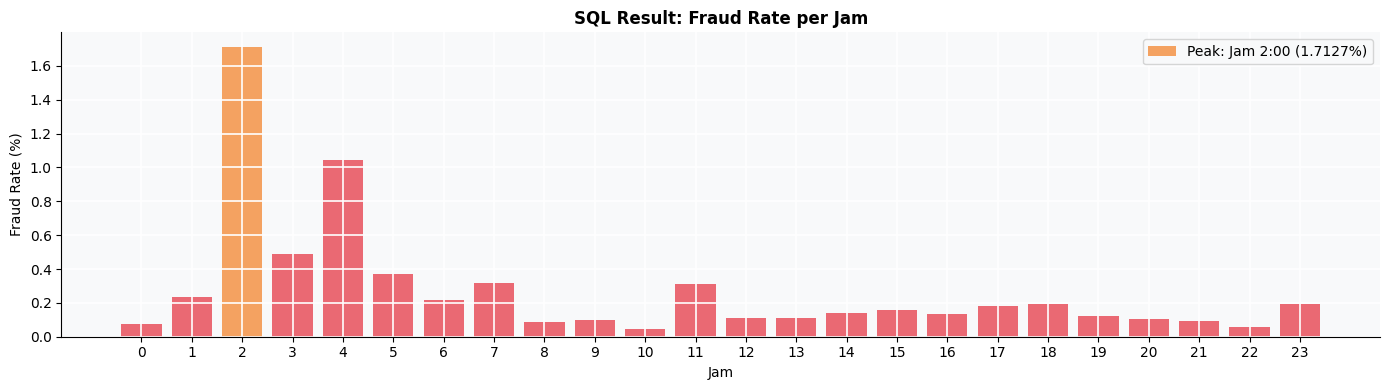

In [4]:
q2 = con.execute("""
    SELECT
        Hour,
        COUNT(*)                                                  AS total_trx,
        SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END)               AS fraud_count,
        SUM(CASE WHEN Class = 0 THEN 1 ELSE 0 END)               AS normal_count,
        ROUND(SUM(Class) * 100.0 / COUNT(*), 4)                  AS fraud_rate_pct,
        ROUND(AVG(CASE WHEN Class=1 THEN Amount END), 2)          AS avg_fraud_amount,
        ROUND(AVG(CASE WHEN Class=0 THEN Amount END), 2)          AS avg_normal_amount
    FROM transactions
    GROUP BY Hour
    ORDER BY Hour
""").df()

print('Q2: Fraud per Jam')
display(q2)

# Visualisasi
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(q2['Hour'], q2['fraud_rate_pct'], color=FRAUD_COLOR, alpha=0.75, width=0.8)
peak = q2.loc[q2['fraud_rate_pct'].idxmax()]
ax.bar(peak['Hour'], peak['fraud_rate_pct'], color=ACCENT_COLOR, alpha=1.0, width=0.8,
       label=f"Peak: Jam {int(peak['Hour'])}:00 ({peak['fraud_rate_pct']}%)")
ax.set_xlabel('Jam')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(24))
ax.set_title('SQL Result: Fraud Rate per Jam', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_sql_01_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Query 3: Fraud Rate per Bracket Amount

Q3: Fraud Rate per Bracket Amount


,amount_bracket,total_trx,fraud_count,fraud_rate_pct,avg_amount,total_amount
0,<$10,98439,222.0,0.2255,3.96,389875.95
1,$10-50,90781,57.0,0.0628,25.96,2356612.28
2,$50-100,37254,56.0,0.1503,73.30,2730609.87
3,$100-500,47366,95.0,0.2006,212.60,10069828.36
4,$500-1K,6202,26.0,0.4192,693.38,4300353.57
5,$1K-5K,2885,9.0,0.3120,1695.40,4891229.40
6,>$5K,55,0.0,0.0000,7710.56,424080.58
7,nan,1825,27.0,1.4795,0.00,0.00


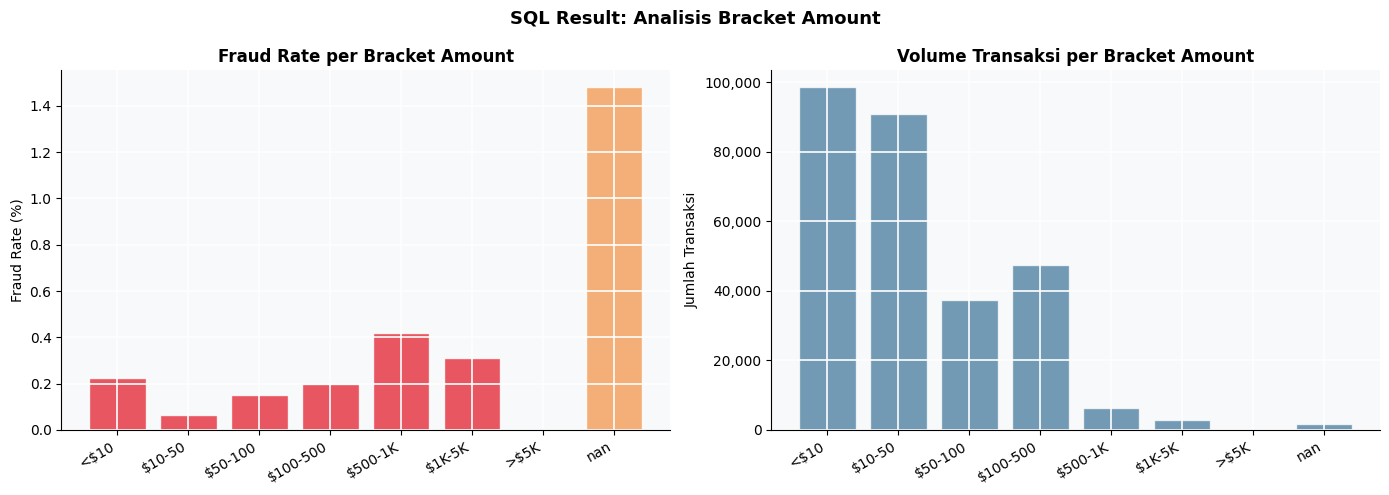

In [5]:
q3 = con.execute("""
    SELECT
        amount_bracket,
        COUNT(*)                                           AS total_trx,
        SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END)        AS fraud_count,
        ROUND(SUM(Class) * 100.0 / COUNT(*), 4)           AS fraud_rate_pct,
        ROUND(AVG(Amount), 2)                              AS avg_amount,
        ROUND(SUM(Amount), 2)                              AS total_amount
    FROM transactions
    GROUP BY amount_bracket
    ORDER BY
        CASE amount_bracket
            WHEN '<$10'      THEN 1
            WHEN '$10-50'    THEN 2
            WHEN '$50-100'   THEN 3
            WHEN '$100-500'  THEN 4
            WHEN '$500-1K'   THEN 5
            WHEN '$1K-5K'    THEN 6
            WHEN '>$5K'      THEN 7
        END
""").df()

print('Q3: Fraud Rate per Bracket Amount')
display(q3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate
colors = [ACCENT_COLOR if r == q3['fraud_rate_pct'].max() else FRAUD_COLOR
          for r in q3['fraud_rate_pct']]
axes[0].bar(q3['amount_bracket'], q3['fraud_rate_pct'], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_xticklabels(q3['amount_bracket'], rotation=30, ha='right')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate per Bracket Amount', fontweight='bold')

# Volume transaksi
axes[1].bar(q3['amount_bracket'], q3['total_trx'], color=NORMAL_COLOR, alpha=0.75, edgecolor='white')
axes[1].set_xticklabels(q3['amount_bracket'], rotation=30, ha='right')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_title('Volume Transaksi per Bracket Amount', fontweight='bold')

plt.suptitle('SQL Result: Analisis Bracket Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_sql_02_amount_bracket.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Query 4: Top 10 Jam dengan Fraud Terbanyak

In [6]:
q4 = con.execute("""
    WITH hourly_stats AS (
        SELECT
            Hour,
            COUNT(*)                                          AS total_trx,
            SUM(CASE WHEN Class = 1 THEN 1 ELSE 0 END)       AS fraud_count,
            ROUND(SUM(Class) * 100.0 / COUNT(*), 4)          AS fraud_rate_pct,
            ROUND(SUM(CASE WHEN Class=1 THEN Amount ELSE 0 END), 2) AS total_fraud_amount
        FROM transactions
        GROUP BY Hour
    )
    SELECT
        Hour,
        fraud_count,
        total_trx,
        fraud_rate_pct,
        total_fraud_amount,
        RANK() OVER (ORDER BY fraud_count DESC)     AS rank_by_count,
        RANK() OVER (ORDER BY fraud_rate_pct DESC)  AS rank_by_rate
    FROM hourly_stats
    ORDER BY rank_by_count
    LIMIT 10
""").df()

print('Q4: Top 10 Jam Paling Rawan Fraud')
display(q4)

Q4: Top 10 Jam Paling Rawan Fraud


,Hour,fraud_count,total_trx,fraud_rate_pct,total_fraud_amount,rank_by_count,rank_by_rate
0,2,57.0,3328,1.7127,4517.98,1,1
1,11,53.0,16856,0.3144,6570.73,2,6
2,18,33.0,17039,0.1937,6345.14,3,9
3,17,29.0,16166,0.1794,3373.50,4,11
4,15,26.0,16461,0.1579,2234.09,5,12
5,7,23.0,7243,0.3175,2757.78,6,5
6,14,23.0,16570,0.1388,3641.12,6,13
7,4,23.0,2209,1.0412,1548.20,6,2
8,16,22.0,16453,0.1337,4505.45,9,14
9,23,21.0,10938,0.1920,3143.12,10,10


---
## Query 5: Deteksi Anomali — Transaksi Fraud Bernilai Besar

Q5: 15 Transaksi Fraud Bernilai Terbesar (Top 10 Percentile)


,amount,jam,V1,V2,V3,V4,V14
0,2125.87,10,-2.0035,-7.1590,-4.0510,1.3096,1.0752
1,1809.68,2,-3.4991,0.2586,-4.4896,4.8539,-3.7380
2,1504.93,18,-1.6002,-3.4881,-6.4593,3.2468,-6.1062
3,1402.16,17,-5.3447,-0.2858,-3.8356,5.3370,-6.0434
4,1389.56,16,-2.3269,-3.3484,-3.5134,3.1751,-5.5869
5,1354.25,18,-2.9238,1.5248,-3.0188,3.2893,-4.8578
6,1335.00,12,-1.2127,-2.4848,-6.3972,3.6706,-4.7997
7,1218.89,5,-12.2240,3.8542,-12.4668,9.6483,-10.1402
8,1096.99,18,-0.0830,-3.9359,-2.6167,0.1633,0.9850
9,996.27,16,-1.6119,-0.4084,-3.8298,6.2495,-1.8081


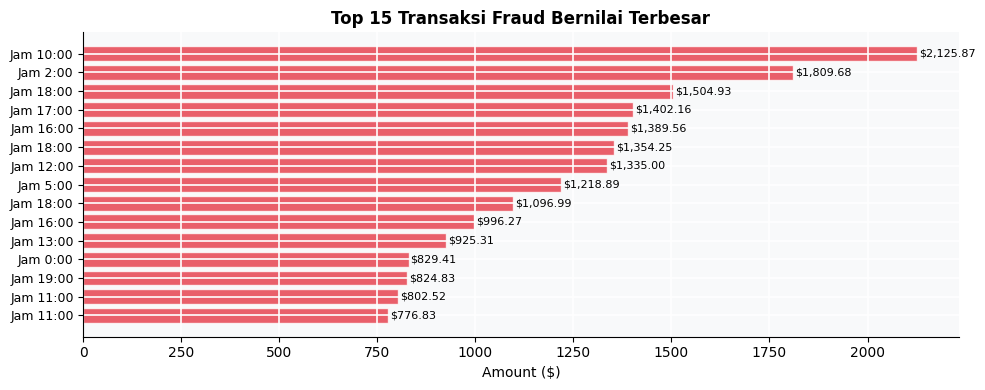

In [7]:
q5 = con.execute("""
    SELECT
        ROUND(Amount, 2)       AS amount,
        Hour                   AS jam,
        ROUND(V1, 4)           AS V1,
        ROUND(V2, 4)           AS V2,
        ROUND(V3, 4)           AS V3,
        ROUND(V4, 4)           AS V4,
        ROUND(V14, 4)          AS V14
    FROM transactions
    WHERE Class = 1
      AND Amount > (
          SELECT PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY Amount)
          FROM transactions
          WHERE Class = 1
      )
    ORDER BY Amount DESC
    LIMIT 15
""").df()

print('Q5: 15 Transaksi Fraud Bernilai Terbesar (Top 10 Percentile)')
display(q5)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(range(len(q5)), q5['amount'], color=FRAUD_COLOR, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(q5)))
ax.set_yticklabels([f"Jam {int(r['jam'])}:00" for _, r in q5.iterrows()], fontsize=9)
ax.set_xlabel('Amount ($)')
ax.set_title('Top 15 Transaksi Fraud Bernilai Terbesar', fontweight='bold')
ax.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, q5['amount'])):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_sql_03_high_value_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Query 6: Perbandingan Statistik Deskriptif SQL vs Pandas

In [8]:
q6 = con.execute("""
    SELECT
        CASE WHEN Class = 0 THEN 'Normal' ELSE 'Fraud' END  AS label,
        COUNT(*)                                             AS n,
        ROUND(AVG(Amount), 4)                                AS mean,
        ROUND(STDDEV(Amount), 4)                             AS std,
        ROUND(MIN(Amount), 4)                                AS min,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP
              (ORDER BY Amount), 4)                          AS q1,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP
              (ORDER BY Amount), 4)                          AS median,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP
              (ORDER BY Amount), 4)                          AS q3,
        ROUND(MAX(Amount), 4)                                AS max
    FROM transactions
    GROUP BY Class
    ORDER BY Class
""").df()

print('Q6: Statistik Deskriptif Amount via SQL')
display(q6)
print('\nHasil ini ekuivalen dengan df.groupby("Class")["Amount"].describe()')

Q6: Statistik Deskriptif Amount via SQL


,label,n,mean,std,min,q1,median,q3,max
0,Normal,284315,88.2910,250.1051,0.0,5.65,22.00,77.05,25691.16
1,Fraud,492,122.2113,256.6833,0.0,1.00,9.25,105.89,2125.87



Hasil ini ekuivalen dengan df.groupby("Class")["Amount"].describe()


---
## Ringkasan SQL Insights

In [9]:
fraud_summary  = q1[q1['Class'] == 1].iloc[0]
normal_summary = q1[q1['Class'] == 0].iloc[0]
peak_hour_row  = q2.loc[q2['fraud_rate_pct'].idxmax()]
peak_bracket   = q3.loc[q3['fraud_rate_pct'].idxmax(), 'amount_bracket']


print('   RINGKASAN SQL INSIGHT — FRAUD DETECTION')
print(f"""
STATISTIK UTAMA
   • Transaksi fraud  : {int(fraud_summary['total_transactions']):,} ({fraud_summary['pct']}%)
   • Avg amount fraud : ${fraud_summary['avg_amount']}
   • Avg amount normal: ${normal_summary['avg_amount']}

POLA WAKTU
   • Jam fraud rate tertinggi : {int(peak_hour_row['Hour'])}:00
     → Fraud rate: {peak_hour_row['fraud_rate_pct']}%
     → Jumlah fraud: {int(peak_hour_row['fraud_count'])} transaksi

POLA AMOUNT
   • Bracket paling rawan : {peak_bracket}
     → Fraud rate tertinggi di range ini

TEMUAN KUNCI UNTUK MODEL ML
   1. Class imbalance ekstrem → wajib handle saat modeling
   2. Ada pola waktu → 'Hour' bisa jadi fitur tambahan
   3. Amount punya distribusi berbeda → perlu scaling
   4. Beberapa transaksi fraud bernilai sangat besar (outlier)
""")
print('SQL Analysis selesai! Lanjut ke Notebook 3: Baseline Model')

   RINGKASAN SQL INSIGHT — FRAUD DETECTION

STATISTIK UTAMA
   • Transaksi fraud  : 492 (0.1727%)
   • Avg amount fraud : $122.21
   • Avg amount normal: $88.29

POLA WAKTU
   • Jam fraud rate tertinggi : 2:00
     → Fraud rate: 1.7127%
     → Jumlah fraud: 57 transaksi

POLA AMOUNT
   • Bracket paling rawan : nan
     → Fraud rate tertinggi di range ini

TEMUAN KUNCI UNTUK MODEL ML
   1. Class imbalance ekstrem → wajib handle saat modeling
   2. Ada pola waktu → 'Hour' bisa jadi fitur tambahan
   3. Amount punya distribusi berbeda → perlu scaling
   4. Beberapa transaksi fraud bernilai sangat besar (outlier)

SQL Analysis selesai! Lanjut ke Notebook 3: Baseline Model
